In [50]:
%reset -f

import numpy as np
import matplotlib.pyplot as plt

# will be used to load MATLAB mat datafile format
from scipy.io import loadmat

In [51]:
# parameters: 
# m = size of the dataset
# n2 = number of neurons in the second layer
# alpha = learning rate for the gradient descent
# Niter = number of iterations if the gradient descent

n2 = 25
alpha = 0.3
Niter = 4000

In [52]:
#  training data stored in arrays X, y
data = loadmat('ex3data1.mat')
X, y_data = data['X'], data['y'].ravel()

# set the zero digit to 0, rather than its mapped 10 in this dataset
y_data[y_data == 10] = 0

# Number of training examples
m = y_data.size

In [53]:
# function used to visualize the data
def displayData(X, example_width=None, figsize=(10, 10)):
    """
    Displays 2D data stored in X in a nice grid.
    """
    # Compute rows, cols
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]  # Promote to a 2 dimensional array
    else:
        raise IndexError('Input X should be 1 or 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n / example_width

    # Compute number of items to display
    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = plt.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        ax.imshow(X[i].reshape(example_width, example_width, order='F'),
                  cmap='Greys', extent=[0, 1, 0, 1])
        ax.axis('off')


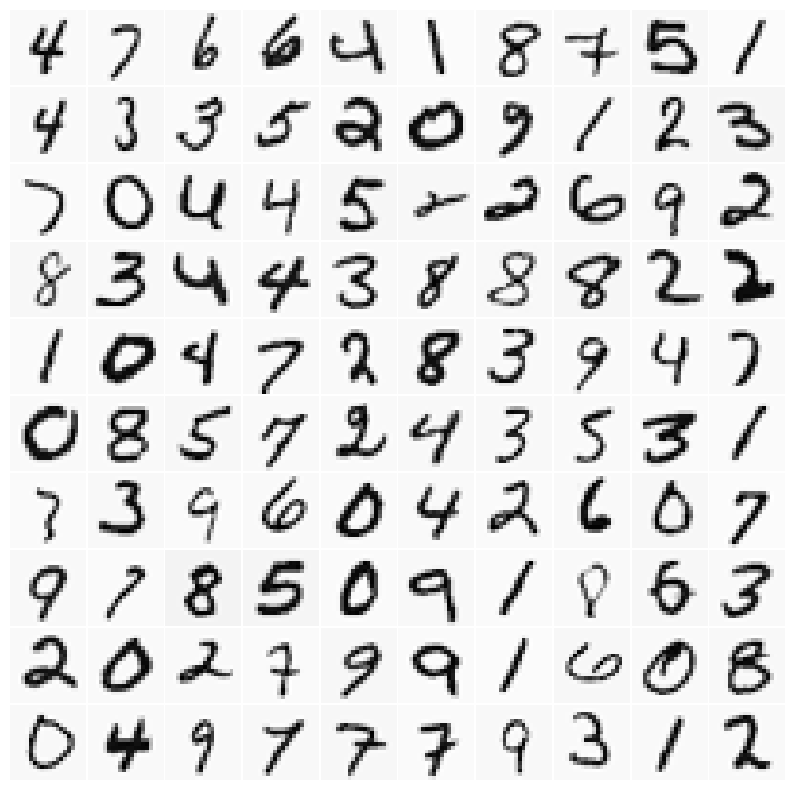

In [54]:
# Randomly select 100 images and display them
rand_indices = np.random.choice(m, 100, replace=False)
sel = X[rand_indices, :]

displayData(sel)

In [55]:
# make sure the images are stored in the column of X
X=X.T
print(X.shape)

(400, 5000)


In [56]:
# you must one hot encode the vector y_data and store in the matrix y
# Initialisation de la matrice y avec des zéros (10 classes x 5000 images)
y = np.zeros((10, m))

# Indexation avancée : on place un 1.0 aux coordonnées (label de l'image, index de l'image)
y[y_data, np.arange(m)] = 1.0

print("Nouvelle dimension de y :", y.shape)

Nouvelle dimension de y : (10, 5000)


In [57]:
# activation function
def sigma(z):
    return 1/(1+np.exp(-z))

In [58]:
# derivative of the activation function
def sigma_prim(z):
    return np.exp(-z)/((1+np.exp(-z))**2)

In [59]:
def softmax(z):
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=0, keepdims=True)

In [60]:
def compute_cost(a3, y, m):
    cost = (-1/m) * np.sum(y*np.log(a3))
    return cost

In [61]:
def predict(a3):
    return np.argmax(a3, axis=0)

In [62]:
# random initialization of the parameters of the neural network

W2 = np.random.randn(n2,1)
b2 = np.random.randn(n2,1)

#avant
#W3 = np.random.randn(1,n2)
#b3 = np.random.randn(1)

W3 = np.random.randn(2, n2)
b3 = np.random.randn(2,1)

In [63]:
def compute_grad(x, y, W2, W3, b2, b3):
    A1 = x

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)

    delta_3 = A3 - y
    delta_2 = (np.transpose(W3)@delta_3)*sigma_prim(Z2)

    dC_W2 = (1/m)*delta_2@np.transpose(A1)
    dC_W3 = (1/m)*delta_3@np.transpose(A2)
    
    dC_b2 = (1/m)*np.sum(delta_2, axis=1).reshape((n2, 1))
    
    # CORRECTION ICI : on utilise y.shape[0] (qui vaut 10) au lieu de 2
    dC_b3 = (1/m)*np.sum(delta_3, axis=1).reshape((y.shape[0], 1))
    
    return dC_W2, dC_W3, dC_b2, dC_b3

In [64]:
# Prediction of the model
def model_predict(X,W2,W3,b2,b3):
    
    A1 = X

    Z2 = W2@A1 + b2
    A2 = sigma(Z2)

    Z3 = W3@A2 + b3
    A3 = softmax(Z3)
    
    return A3

In [65]:
# 1. Initialisation avec les nouvelles dimensions
# Entrées = 400 pixels, n2 = 25 (d'après ta cellule 2), Sorties = 10 classes
W2 = np.random.randn(n2, 400)
b2 = np.random.randn(n2, 1)

W3 = np.random.randn(10, n2)
b3 = np.random.randn(10, 1)

# 2. Boucle d'apprentissage
Cost = np.zeros(Niter)

for j in range(Niter):
    y_pred = model_predict(X, W2, W3, b2, b3)
    Cost[j] = compute_cost(y_pred, y, m)
        
    dC_dW2, dC_dW3, dC_db2, dC_db3 = compute_grad(X, y, W2, W3, b2, b3)

    W2 = W2 - alpha * dC_dW2
    W3 = W3 - alpha * dC_dW3
    b2 = b2 - alpha * dC_db2
    b3 = b3 - alpha * dC_db3

# 3. Évaluation de la précision (Accuracy)
y_pred = model_predict(X, W2, W3, b2, b3)
predictions = np.argmax(y_pred, axis=0)

# Comme on a déjà y_data qui contient les vrais labels de 0 à 9, on l'utilise directement
print("Accuracy sur le set d'entraînement :", 100 * np.mean(predictions == y_data), "%")

Accuracy sur le set d'entraînement : 94.72 %


In [66]:
from sklearn.utils import shuffle

# 1. Brassage des données (Shuffling)
# On transpose temporairement pour mélanger les images (colonnes -> lignes)
X_shuffled, Y_shuffled = shuffle(X.T, y.T, random_state=42)
X_shuffled = X_shuffled.T
Y_shuffled = Y_shuffled.T

# 2. Séparation Train / Test
m_train = 4000

X_train = X_shuffled[:, :m_train]
Y_train = Y_shuffled[:, :m_train]

X_test = X_shuffled[:, m_train:]
Y_test = Y_shuffled[:, m_train:]

print("Taille X_train :", X_train.shape)
print("Taille Y_train :", Y_train.shape)
print("Taille X_test :", X_test.shape)
print("Taille Y_test :", Y_test.shape)
print("-" * 30)

# 3. Ré-initialisation des paramètres pour le nouvel apprentissage (sur 4000 données)
W2 = np.random.randn(n2, 400)
b2 = np.random.randn(n2, 1)
W3 = np.random.randn(10, n2)
b3 = np.random.randn(10, 1)

Cost = np.zeros(Niter)

# 4. Apprentissage (Uniquement sur le Train set)
for j in range(Niter):
    y_pred = model_predict(X_train, W2, W3, b2, b3)
    Cost[j] = compute_cost(y_pred, Y_train, m_train)
        
    dC_dW2, dC_dW3, dC_db2, dC_db3 = compute_grad(X_train, Y_train, W2, W3, b2, b3)

    W2 = W2 - alpha * dC_dW2
    W3 = W3 - alpha * dC_dW3
    b2 = b2 - alpha * dC_db2
    b3 = b3 - alpha * dC_db3

# 5. Évaluation et comparaison des performances
# Accuracy sur l'entraînement
pred_train = model_predict(X_train, W2, W3, b2, b3)
labels_train = np.argmax(pred_train, axis=0)
vrais_labels_train = np.argmax(Y_train, axis=0)
acc_train = 100 * np.mean(labels_train == vrais_labels_train)
print(f"Accuracy sur l'entraînement (4000 images) : {acc_train:.2f} %")

# Accuracy sur le test
pred_test = model_predict(X_test, W2, W3, b2, b3)
labels_test = np.argmax(pred_test, axis=0)
vrais_labels_test = np.argmax(Y_test, axis=0)
acc_test = 100 * np.mean(labels_test == vrais_labels_test)
print(f"Accuracy sur le test (1000 images inédites) : {acc_test:.2f} %")

Taille X_train : (400, 4000)
Taille Y_train : (10, 4000)
Taille X_test : (400, 1000)
Taille Y_test : (10, 1000)
------------------------------
Accuracy sur l'entraînement (4000 images) : 93.97 %
Accuracy sur le test (1000 images inédites) : 88.80 %
